# Airbnb Pricing Advisor
### DNSC 4289/6317 - Group 8
Hana Aglan, Darshan Dullabh, David Porudominsky Rotstain, May Khin Maung Soe, Tsion Temesgen

## 1. Data Collection & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

listings = pd.read_csv('listings.csv')
events = pd.read_csv('events_dc.csv')

print("Listings shape:", listings.shape)
print("Events shape:", events.shape)
events.head()

Listings shape: (6374, 79)
Events shape: (50, 10)


,event_name,date,time,venue,city,state,latitude,longitude,category,url
0,World Cup: Match 4 - Group D - USA vs Paraguay,2026-06-12,18:00:00,SoFi Stadium,Inglewood,CA,33.956299,-118.358498,Sports,https://www.ticketmaster.com/event/Z7r9jZ1A74333
1,World Cup: Match 5 ??? Group C - Haiti vs Scot...,2026-06-13,21:00:00,Gillette Stadium,Foxborough,MA,42.063099,-71.245598,Sports,https://www.ticketmaster.com/event/Z7r9jZ1A74334
2,World Cup: Match 8 ??? Group B- Qatar vs Switz...,2026-06-13,12:00:00,Levi's Stadium,Santa Clara,CA,37.393398,-121.965500,Sports,https://www.ticketmaster.com/event/Z7r9jZ1A7433K
3,World Cup: Match 7 ??? Group C - Brazil vs Mor...,2026-06-13,18:00:00,MetLife Stadium,East Rutherford,NJ,40.812401,-74.076302,Sports,https://www.ticketmaster.com/event/Z7r9jZ1A7433p
4,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,19:00:00,Lincoln Financial Field,Philadelphia,PA,39.910999,-75.153397,Sports,https://www.ticketmaster.com/event/Z7r9jZ1A74339


## 2. Data Preparation & Merging

In [2]:
listings = listings[['id','latitude','longitude','price','bedrooms',
                          'accommodates','room_type','neighbourhood_cleansed',
                          'review_scores_rating','minimum_nights']]
listings['price'] = listings['price'].replace(r'[\$,]', '', regex=True).astype(float)
listings = listings[listings['price'] > 0].dropna(subset=['price'])
print(listings.shape)
listings.head()

(4892, 10)


,id,latitude,longitude,price,bedrooms,accommodates,room_type,neighbourhood_cleansed,review_scores_rating,minimum_nights
0,3344,38.90145,-77.02679,150.0,1.0,2,Entire home/apt,"Downtown, Chinatown, Penn Quarters, Mount Vern...",5.00,59
1,3686,38.86339,-76.98889,61.0,1.0,1,Private room,Historic Anacostia,4.65,31
2,3943,38.91195,-77.00456,75.0,1.0,2,Private room,"Edgewood, Bloomingdale, Truxton Circle, Eckington",4.86,1
3,4197,38.88719,-76.99472,90.0,1.0,1,Private room,"Capitol Hill, Lincoln Park",4.88,4
4,4529,38.90585,-76.94469,65.0,1.0,2,Private room,"Eastland Gardens, Kenilworth",4.65,30


In [3]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def nearest_event(row):
    distances = events.apply(lambda e: haversine(row['latitude'], row['longitude'],
                             e['latitude'], e['longitude']), axis=1)
    idx = distances.idxmin()
    return pd.Series({'nearest_event': events.loc[idx,'event_name'],
                      'event_date': events.loc[idx,'date'],
                      'event_category': events.loc[idx,'category'],
                      'distance_to_event_km': distances.min()})

merged = pd.read_csv('merged_data.csv')
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (6374, 14)


,id,latitude,longitude,price,bedrooms,accommodates,room_type,neighbourhood_cleansed,review_scores_rating,minimum_nights,nearest_event,event_date,event_category,distance_to_event_km
0,3344,38.90145,-77.02679,150.0,1.0,2,Entire home/apt,"Downtown, Chinatown, Penn Quarters, Mount Vern...",5.00,59,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,Sports,196.227360
1,3686,38.86339,-76.98889,61.0,1.0,1,Private room,Historic Anacostia,4.65,31,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,Sports,196.084706
2,3943,38.91195,-77.00456,75.0,1.0,2,Private room,"Edgewood, Bloomingdale, Truxton Circle, Eckington",4.86,1,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,Sports,193.983395
3,4197,38.88719,-76.99472,90.0,1.0,1,Private room,"Capitol Hill, Lincoln Park",4.88,4,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,Sports,194.908957
4,4529,38.90585,-76.94469,65.0,1.0,2,Private room,"Eastland Gardens, Kenilworth",4.65,30,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,Sports,190.193334


## 3. Feature Engineering

In [4]:
merged['is_event_nearby'] = (merged['distance_to_event_km'] < 10).astype(int)
merged['is_sports'] = (merged['event_category'] == 'Sports').astype(int)
merged = pd.get_dummies(merged, columns=['room_type'], drop_first=True)

features = ['bedrooms','accommodates','review_scores_rating',
            'minimum_nights','distance_to_event_km','is_event_nearby','is_sports']
features += [c for c in merged.columns if c.startswith('room_type_')]
print("Features:", features)

Features: ['bedrooms', 'accommodates', 'review_scores_rating', 'minimum_nights', 'distance_to_event_km', 'is_event_nearby', 'is_sports', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


## 4. Model Training & Evaluation

In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

df = merged.dropna(subset=features+['price'])
X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}
for name, model in [('Linear Regression', LinearRegression()),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
                    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42))]:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'MAPE': f'{mape:.2%}', 'RMSE': f'${rmse:.2f}'}
    print(f"{name}: MAPE={mape:.2%}, RMSE=${rmse:.2f}")

pd.DataFrame(results).T

Linear Regression: MAPE=340.35%, RMSE=$1672.67
Random Forest: MAPE=56.27%, RMSE=$690.82
Gradient Boosting: MAPE=55.54%, RMSE=$273.22


,MAPE,RMSE
Linear Regression,340.35%,$1672.67
Random Forest,56.27%,$690.82
Gradient Boosting,55.54%,$273.22


## 5. Pricing Recommendations

In [6]:
recommendations = pd.read_csv('pricing_recommendations.csv')
print("Action breakdown:")
print(recommendations['action'].value_counts())
recommendations.head(10)

Action breakdown:
action
RAISE       2056
DISCOUNT    1384
HOLD         797
Name: count, dtype: int64


,id,baseline_price,recommended_price,price_uplift,action,nearest_event,event_date,distance_to_event_km
0,3344,150.0,186.235689,36.235689,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,196.227360
1,3686,61.0,63.607586,2.607586,HOLD,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,196.084706
2,3943,75.0,87.206978,12.206978,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,193.983395
3,4197,90.0,79.522678,-10.477322,DISCOUNT,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,194.908957
4,4529,65.0,44.806823,-20.193177,DISCOUNT,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,190.193334
5,11785,91.0,131.113543,40.113543,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,198.143707
6,12442,52.0,63.607586,11.607586,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,198.114522
7,13744,100.0,94.644308,-5.355692,HOLD,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,194.830487
8,14218,52.0,63.607586,11.607586,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,198.183015
9,17131,52.0,63.607586,11.607586,RAISE,World Cup: Match 9 ??? Group E - Ivory Coast v...,2026-06-14,198.169350


## 6. Visualizations

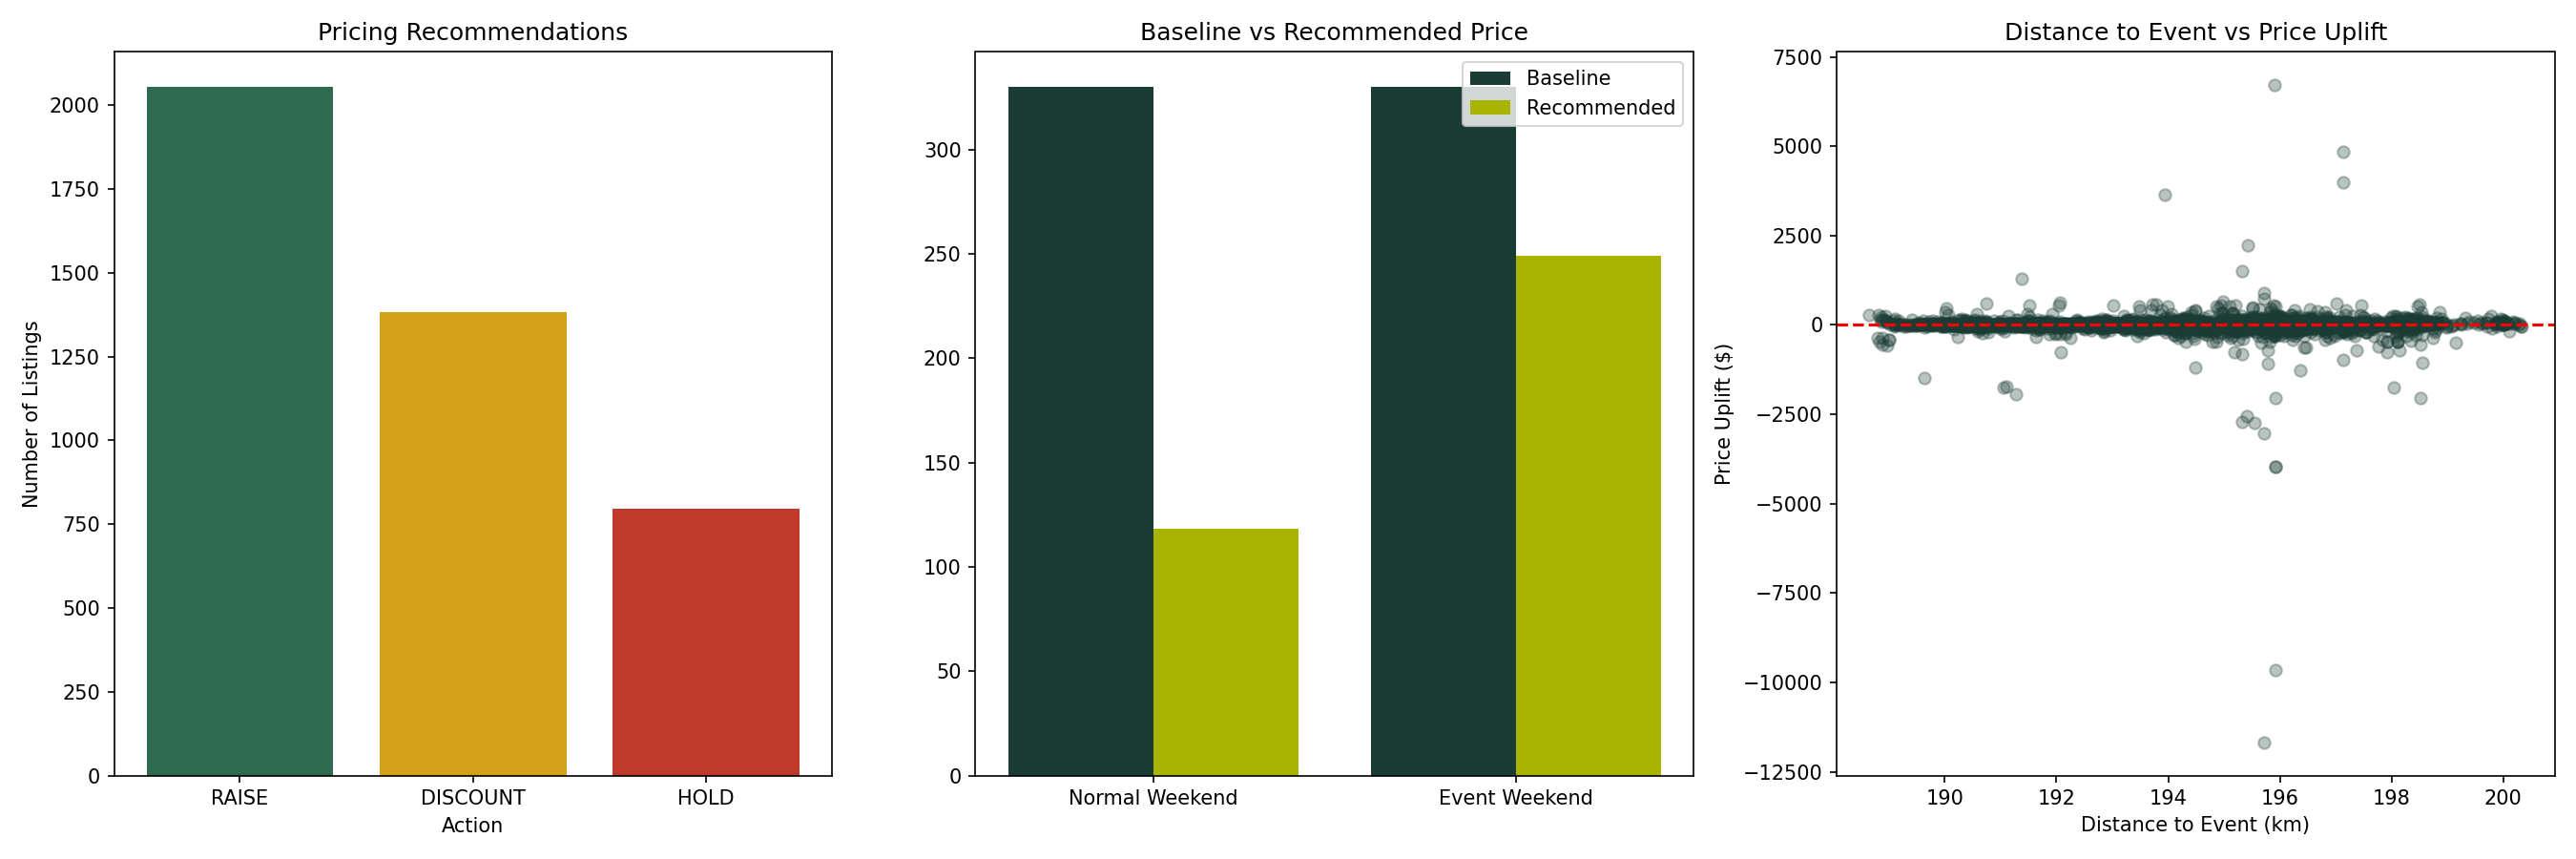

In [7]:
from IPython.display import Image
Image('pricing_charts.png')